## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Carga y Exploración del Dataset

In [2]:
# Cargar el dataset con synonym augmentation
import os

# Usar el dataset con synonym augmentation
df = pd.read_csv('../resources/dataset/synonym_youtoxic_english_1000.csv', index_col=0)
print("✓ Usando dataset con SYNONYM AUGMENTATION")

# Definir las etiquetas a usar
labels = ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

print(f"\nForma del dataset: {df.shape}")
print(f"Etiquetas a analizar: {labels}")
print("\nPrimeras filas:")
df.head()

✓ Usando dataset con SYNONYM AUGMENTATION

Forma del dataset: (3751, 15)
Etiquetas a analizar: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

Primeras filas:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement embody not train to shoot to a...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement make up not trained to shoot t...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Legal philosophy enforcement is not trained to...,True,True,False,False,False,False,False,False,False,False,False,False


In [3]:
# Información del dataset
print("Información del dataset:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas de las etiquetas:")
print(df[labels].describe())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 3751 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        3751 non-null   object
 1   VideoId          3751 non-null   object
 2   Text             3751 non-null   object
 3   IsToxic          3751 non-null   bool  
 4   IsAbusive        3751 non-null   bool  
 5   IsThreat         3751 non-null   bool  
 6   IsProvocative    3751 non-null   bool  
 7   IsObscene        3751 non-null   bool  
 8   IsHatespeech     3751 non-null   bool  
 9   IsRacist         3751 non-null   bool  
 10  IsNationalist    3751 non-null   bool  
 11  IsSexist         3751 non-null   bool  
 12  IsHomophobic     3751 non-null   bool  
 13  IsReligiousHate  3751 non-null   bool  
 14  IsRadicalism     3751 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 161.2+ KB

Valores nulos por columna:
CommentId          0
VideoId 

## 3. Análisis de Distribución de Etiquetas

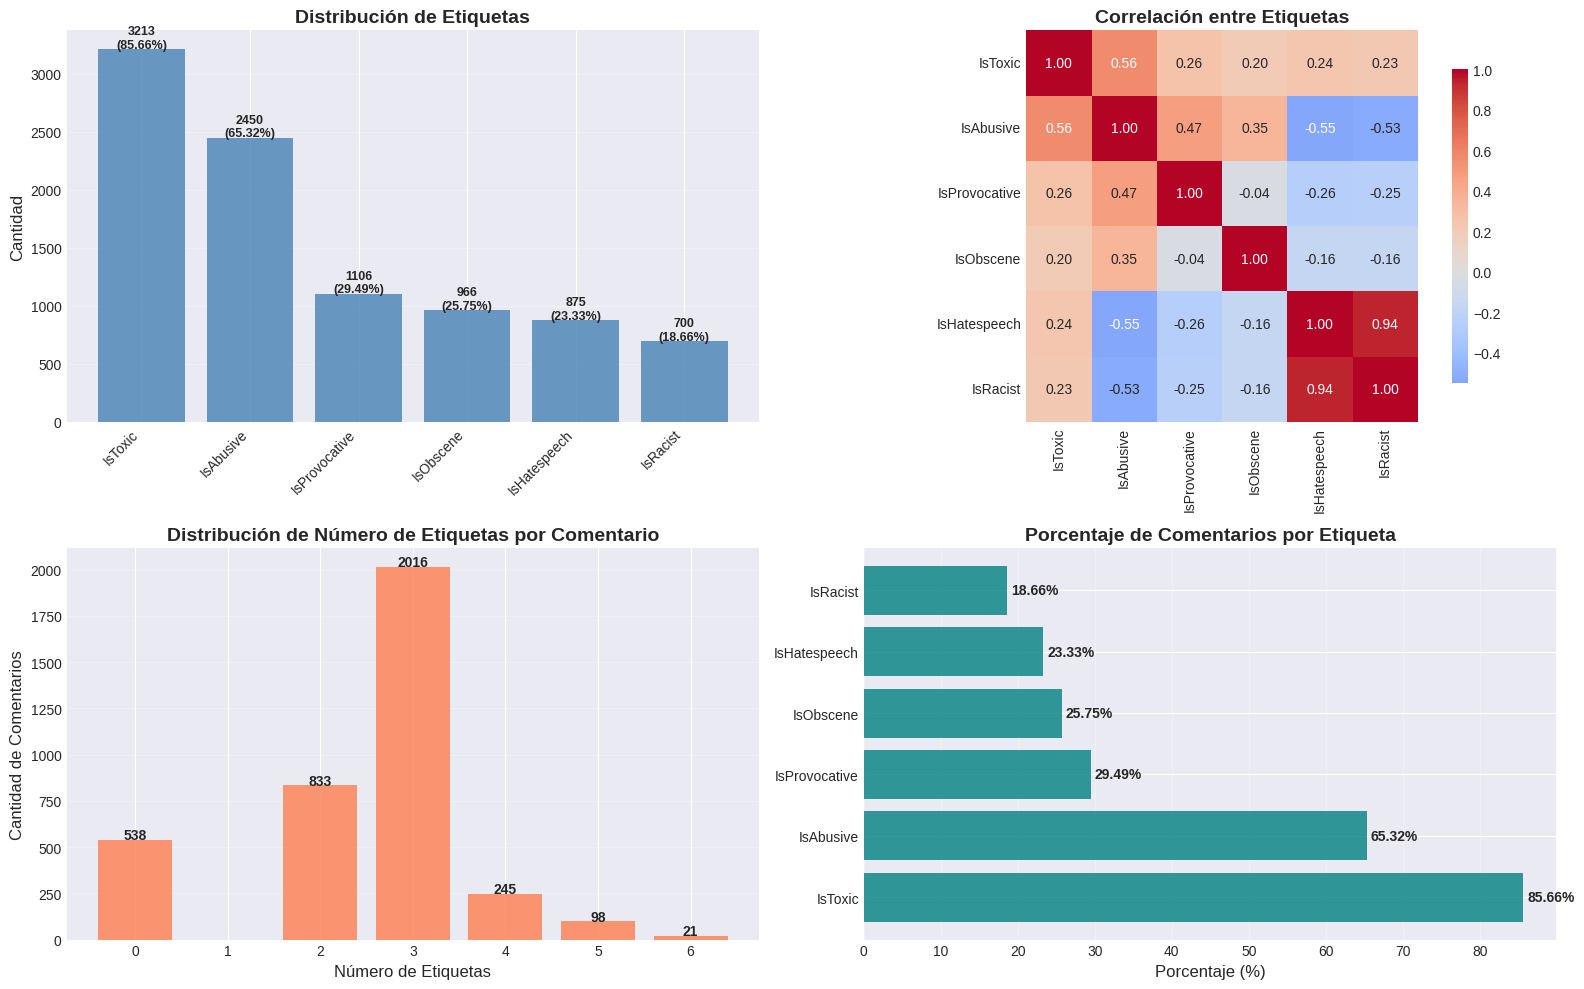


Balance del dataset:
IsToxic: 3213 (85.66%)
IsAbusive: 2450 (65.32%)
IsProvocative: 1106 (29.49%)
IsObscene: 700 (18.66%)
IsHatespeech: 966 (25.75%)
IsRacist: 875 (23.33%)

Promedio de etiquetas por comentario: 2.48
Comentarios sin etiquetas: 538
Comentarios con al menos una etiqueta: 3213


In [4]:
# Distribución de las etiquetas
label_counts = df[labels].sum().sort_values(ascending=False)
label_percentages = (label_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Gráfico 1: Conteo por etiqueta
axes[0].bar(range(len(labels)), label_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].set_title('Distribución de Etiquetas', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, f'{v}\n({label_percentages.values[i]}%)', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Heatmap de correlaciones
corr_matrix = df[labels].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Correlación entre Etiquetas', fontsize=14, fontweight='bold')

# Gráfico 3: Distribución de número de etiquetas por comentario
num_labels = df[labels].sum(axis=1)
label_dist = num_labels.value_counts().sort_index()
axes[2].bar(label_dist.index, label_dist.values, color='coral', alpha=0.8)
axes[2].set_xlabel('Número de Etiquetas', fontsize=12)
axes[2].set_ylabel('Cantidad de Comentarios', fontsize=12)
axes[2].set_title('Distribución de Número de Etiquetas por Comentario', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in zip(label_dist.index, label_dist.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 4: Porcentaje de cada etiqueta
axes[3].barh(range(len(labels)), label_percentages.values, color='teal', alpha=0.8)
axes[3].set_yticks(range(len(labels)))
axes[3].set_yticklabels(labels)
axes[3].set_xlabel('Porcentaje (%)', fontsize=12)
axes[3].set_title('Porcentaje de Comentarios por Etiqueta', fontsize=14, fontweight='bold')
axes[3].grid(axis='x', alpha=0.3)
for i, v in enumerate(label_percentages.values):
    axes[3].text(v + 0.5, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
for label in labels:
    count = df[label].sum()
    pct = count / len(df) * 100
    print(f"{label}: {count} ({pct:.2f}%)")

print(f"\nPromedio de etiquetas por comentario: {num_labels.mean():.2f}")
print(f"Comentarios sin etiquetas: {(num_labels == 0).sum()}")
print(f"Comentarios con al menos una etiqueta: {(num_labels > 0).sum()}")

## 4. Análisis de Longitud de Texto

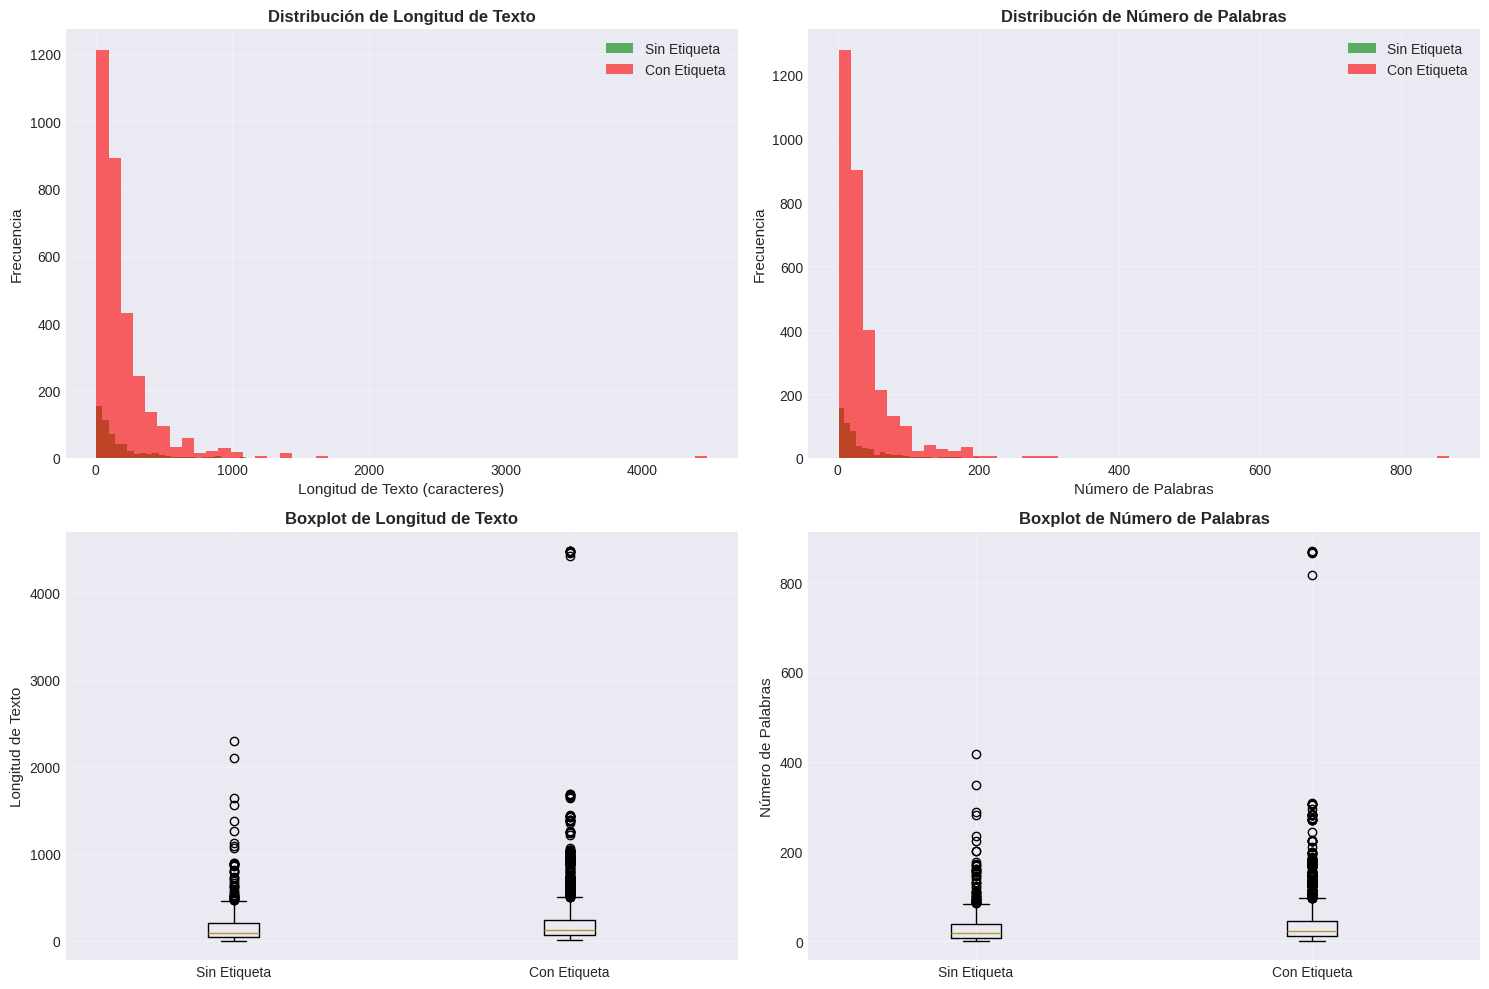


Estadísticas de texto por presencia de etiquetas:
          text_length                                                    \
                count        mean         std  min   25%    50%     75%   
has_label                                                                 
False           538.0  182.262082  252.295702  3.0  44.0   96.0  210.75   
True           3213.0  205.036415  294.791247  5.0  64.0  129.0  241.00   

                  word_count                                               \
              max      count       mean        std  min   25%   50%   75%   
has_label                                                                   
False      2292.0      538.0  33.065056  45.165137  1.0   8.0  18.0  38.0   
True       4474.0     3213.0  38.133831  56.258284  1.0  11.0  23.0  45.0   

                  
             max  
has_label         
False      418.0  
True       869.0  


In [5]:
# Análisis de longitud de texto
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

# Crear una columna indicando si tiene al menos una etiqueta
df['has_label'] = df[labels].sum(axis=1) > 0

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de longitud de texto
axes[0, 0].hist(df[df['has_label']==False]['text_length'], bins=50, alpha=0.6, label='Sin Etiqueta', color='green')
axes[0, 0].hist(df[df['has_label']==True]['text_length'], bins=50, alpha=0.6, label='Con Etiqueta', color='red')
axes[0, 0].set_xlabel('Longitud de Texto (caracteres)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de Longitud de Texto', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Distribución de número de palabras
axes[0, 1].hist(df[df['has_label']==False]['word_count'], bins=50, alpha=0.6, label='Sin Etiqueta', color='green')
axes[0, 1].hist(df[df['has_label']==True]['word_count'], bins=50, alpha=0.6, label='Con Etiqueta', color='red')
axes[0, 1].set_xlabel('Número de Palabras', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Número de Palabras', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Boxplot de longitud de texto
axes[1, 0].boxplot([df[df['has_label']==False]['text_length'], df[df['has_label']==True]['text_length']],
                    labels=['Sin Etiqueta', 'Con Etiqueta'])
axes[1, 0].set_ylabel('Longitud de Texto', fontsize=11)
axes[1, 0].set_title('Boxplot de Longitud de Texto', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Boxplot de número de palabras
axes[1, 1].boxplot([df[df['has_label']==False]['word_count'], df[df['has_label']==True]['word_count']],
                    labels=['Sin Etiqueta', 'Con Etiqueta'])
axes[1, 1].set_ylabel('Número de Palabras', fontsize=11)
axes[1, 1].set_title('Boxplot de Número de Palabras', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstadísticas de texto por presencia de etiquetas:")
print(df.groupby('has_label')[['text_length', 'word_count']].describe())

## 5. Preprocesamiento de Texto

In [6]:
def clean_text(text):
    """Limpia el texto para el procesamiento"""
    if pd.isna(text):
        return ""
    
    # Convertir a minúsculas
    text = text.lower()
    
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Eliminar menciones y hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Eliminar caracteres especiales y números (mantener letras y espacios)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar limpieza
print("Limpiando texto...")
df['cleaned_text'] = df['Text'].apply(clean_text)

# Eliminar filas con texto vacío
df = df[df['cleaned_text'].str.len() > 0]

print(f"Filas después de limpieza: {len(df)}")
print("\nEjemplos de texto limpio:")
for i in range(3):
    print(f"\nOriginal: {df.iloc[i]['Text'][:100]}...")
    print(f"Limpio: {df.iloc[i]['cleaned_text'][:100]}...")

Limpiando texto...
Filas después de limpieza: 3749

Ejemplos de texto limpio:

Original: If only people would just take a step back and not make this case about them, because it wasn't abou...
Limpio: if only people would just take a step back and not make this case about them because it wasnt about ...

Original: Law enforcement is not trained to shoot to apprehend.  They are trained to shoot to kill.  And I tha...
Limpio: law enforcement is not trained to shoot to apprehend they are trained to shoot to kill and i thank w...

Original: Law enforcement embody not train to shoot to apprehend. They be prepare to fritter away to vote down...
Limpio: law enforcement embody not train to shoot to apprehend they be prepare to fritter away to vote down ...


## 6. División del Dataset (Train-Validate-Test Split)

In [7]:
# Preparar X e y
X = df['cleaned_text']
y = df[labels].astype(int)

print("="*80)
print("ESTRATEGIA: TRAIN-VALIDATE-TEST SPLIT")
print("="*80)
print("""
1. División inicial: 80% (Train+Val) y 20% (Test)
2. El conjunto Test se guarda y NO se usa para entrenar ni optimizar
3. División del 80%: 80% Train y 20% Validation
4. Entrenamiento y optimización con Train y Validation
5. Evaluación final con Test (datos nunca vistos por el modelo)
""")

# PASO 1: Primera división - Separar Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y['IsToxic']
)

# PASO 2: Segunda división - Separar Train (80% del 80%) y Validation (20% del 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp['IsToxic']
)

print(f"\n{'='*80}")
print("DISTRIBUCIÓN DE DATOS:")
print(f"{'='*80}")
print(f"Dataset completo:          {len(X):>6} muestras (100.0%)")
print(f"Conjunto de Train:         {len(X_train):>6} muestras ({len(X_train)/len(X)*100:>5.1f}%)")
print(f"Conjunto de Validation:    {len(X_val):>6} muestras ({len(X_val)/len(X)*100:>5.1f}%)")
print(f"Conjunto de Test:          {len(X_test):>6} muestras ({len(X_test)/len(X)*100:>5.1f}%)")

print(f"\n{'='*80}")
print("DISTRIBUCIÓN DE ETIQUETAS:")
print(f"{'='*80}")
print(f"\n{'Etiqueta':<15} {'Train':>10} {'Validation':>12} {'Test':>10}")
print("-" * 80)
for label in labels:
    print(f"{label:<15} {y_train[label].sum():>10} {y_val[label].sum():>12} {y_test[label].sum():>10}")
print("="*80)

ESTRATEGIA: TRAIN-VALIDATE-TEST SPLIT

1. División inicial: 80% (Train+Val) y 20% (Test)
2. El conjunto Test se guarda y NO se usa para entrenar ni optimizar
3. División del 80%: 80% Train y 20% Validation
4. Entrenamiento y optimización con Train y Validation
5. Evaluación final con Test (datos nunca vistos por el modelo)


DISTRIBUCIÓN DE DATOS:
Dataset completo:            3749 muestras (100.0%)
Conjunto de Train:           2399 muestras ( 64.0%)
Conjunto de Validation:       600 muestras ( 16.0%)
Conjunto de Test:             750 muestras ( 20.0%)

DISTRIBUCIÓN DE ETIQUETAS:

Etiqueta             Train   Validation       Test
--------------------------------------------------------------------------------
IsToxic               2055          514        643
IsAbusive             1574          400        476
IsProvocative          699          182        225
IsObscene              435          126        139
IsHatespeech           608          149        208
IsRacist               546

## 7. Vectorización con TF-IDF

In [8]:
# Vectorización TF-IDF con parámetros para evitar overfitting
tfidf = TfidfVectorizer(
    max_features=5000,  # Limitar características para evitar overfitting
    min_df=2,           # Ignorar términos muy raros
    max_df=0.8,         # Ignorar términos muy comunes
    ngram_range=(1, 2), # Unigramas y bigramas
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

print("Vectorizando texto con TF-IDF...")
print("\nIMPORTANTE: El vectorizador se entrena SOLO con datos de Train")
print("Validation y Test se transforman usando el vectorizador ya entrenado\n")

# Entrenar vectorizador SOLO con datos de Train
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformar Validation y Test (sin re-entrenar el vectorizador)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Forma de X_train_tfidf:      {X_train_tfidf.shape}")
print(f"Forma de X_val_tfidf:        {X_val_tfidf.shape}")
print(f"Forma de X_test_tfidf:       {X_test_tfidf.shape}")
print(f"\nNúmero de características: {len(tfidf.get_feature_names_out())}")

Vectorizando texto con TF-IDF...

IMPORTANTE: El vectorizador se entrena SOLO con datos de Train
Validation y Test se transforman usando el vectorizador ya entrenado

Forma de X_train_tfidf:      (2399, 5000)
Forma de X_val_tfidf:        (600, 5000)
Forma de X_test_tfidf:       (750, 5000)

Número de características: 5000
Forma de X_train_tfidf:      (2399, 5000)
Forma de X_val_tfidf:        (600, 5000)
Forma de X_test_tfidf:       (750, 5000)

Número de características: 5000


## 8. Entrenamiento del Modelo SVM Multi-Etiqueta

### 8.1 Modelo Base

In [9]:
# Entrenar modelo SVM multi-etiqueta con regularización
# Usamos OneVsRestClassifier para clasificación multi-etiqueta
print("="*80)
print("ENTRENANDO MODELO SVM MULTI-ETIQUETA")
print("="*80)
print("\nIMPORTANTE: El modelo se entrena SOLO con datos de Train")
print("Validation se usa para calcular overfitting durante el entrenamiento")
print("Test se reserva para la evaluación final\n")

# C más bajo = más regularización = menos overfitting
# class_weight='balanced' ajusta automáticamente los pesos para clases desbalanceadas
base_svm = LinearSVC(C=0.1, class_weight='balanced', random_state=42, max_iter=2000, dual=False)
svm_multilabel = OneVsRestClassifier(base_svm)

# Entrenar SOLO con Train
svm_multilabel.fit(X_train_tfidf, y_train)

# Predicciones en Train y Validation (para calcular overfitting)
y_train_pred = svm_multilabel.predict(X_train_tfidf)
y_val_pred = svm_multilabel.predict(X_val_tfidf)

# Predicciones en Test (para evaluación final)
y_test_pred = svm_multilabel.predict(X_test_tfidf)

print("✓ Modelo entrenado exitosamente")
print(f"✓ Predicciones generadas para Train, Validation y Test")

ENTRENANDO MODELO SVM MULTI-ETIQUETA

IMPORTANTE: El modelo se entrena SOLO con datos de Train
Validation se usa para calcular overfitting durante el entrenamiento
Test se reserva para la evaluación final

✓ Modelo entrenado exitosamente
✓ Predicciones generadas para Train, Validation y Test


### 8.2 Evaluación por Etiqueta

In [10]:
# Función para evaluar con Train-Validate-Test
def evaluate_multilabel_model_tvt(y_train_true, y_train_pred, y_val_true, y_val_pred, y_test_true, y_test_pred, label_names):
    """Evalúa el modelo multi-etiqueta con Train-Validate-Test split"""
    
    results = []
    
    print(f"\n{'='*110}")
    print(f"EVALUACIÓN DEL MODELO MULTI-ETIQUETA (Train-Validate-Test)")
    print(f"{'='*110}")
    
    print(f"\n{'Etiqueta':<15} {'Train F1':>10} {'Val F1':>10} {'Test F1':>10} {'Train-Val':>12} {'Train-Test':>12} {'Overfitting':>15}")
    print("-" * 110)
    
    for i, label in enumerate(label_names):
        # Métricas de Train
        train_acc = accuracy_score(y_train_true.iloc[:, i], y_train_pred[:, i])
        train_f1 = f1_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_prec = precision_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_rec = recall_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        
        # Métricas de Validation
        val_acc = accuracy_score(y_val_true.iloc[:, i], y_val_pred[:, i])
        val_f1 = f1_score(y_val_true.iloc[:, i], y_val_pred[:, i], zero_division=0)
        val_prec = precision_score(y_val_true.iloc[:, i], y_val_pred[:, i], zero_division=0)
        val_rec = recall_score(y_val_true.iloc[:, i], y_val_pred[:, i], zero_division=0)
        
        # Métricas de Test
        test_acc = accuracy_score(y_test_true.iloc[:, i], y_test_pred[:, i])
        test_f1 = f1_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_prec = precision_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_rec = recall_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        
        # Diferencias (para detectar overfitting)
        diff_train_val = abs(train_f1 - val_f1) * 100
        diff_train_test = abs(train_f1 - test_f1) * 100
        
        # Estado de overfitting
        if diff_train_val < 5:
            status = "✓ OK"
        elif diff_train_val < 10:
            status = "⚠ Leve"
        else:
            status = "❌ Alto"
        
        print(f"{label:<15} {train_f1:>10.4f} {val_f1:>10.4f} {test_f1:>10.4f} {diff_train_val:>11.2f}% {diff_train_test:>11.2f}% {status:>15}")
        
        results.append({
            'label': label,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'train_f1': train_f1,
            'val_f1': val_f1,
            'test_f1': test_f1,
            'train_prec': train_prec,
            'val_prec': val_prec,
            'test_prec': test_prec,
            'train_rec': train_rec,
            'val_rec': val_rec,
            'test_rec': test_rec,
            'diff_train_val': diff_train_val,
            'diff_train_test': diff_train_test
        })
    
    print("-" * 110)
    
    # Promedios
    avg_train_f1 = np.mean([r['train_f1'] for r in results])
    avg_val_f1 = np.mean([r['val_f1'] for r in results])
    avg_test_f1 = np.mean([r['test_f1'] for r in results])
    avg_diff_train_val = np.mean([r['diff_train_val'] for r in results])
    
    print(f"{'PROMEDIO':<15} {avg_train_f1:>10.4f} {avg_val_f1:>10.4f} {avg_test_f1:>10.4f} {avg_diff_train_val:>11.2f}%")
    
    # Métricas globales
    hamming_train = hamming_loss(y_train_true, y_train_pred)
    hamming_val = hamming_loss(y_val_true, y_val_pred)
    hamming_test = hamming_loss(y_test_true, y_test_pred)
    
    print(f"\n{'='*110}")
    print(f"MÉTRICAS GLOBALES:")
    print(f"{'='*110}")
    print(f"Hamming Loss Train:      {hamming_train:.4f}")
    print(f"Hamming Loss Validation: {hamming_val:.4f}")
    print(f"Hamming Loss Test:       {hamming_test:.4f}")
    
    # Verificar overfitting
    max_diff_train_val = max([r['diff_train_val'] for r in results])
    
    print(f"\n{'='*110}")
    print(f"ANÁLISIS DE OVERFITTING (Train vs Validation):")
    print(f"{'='*110}")
    print(f"Diferencia máxima en F1-Score: {max_diff_train_val:.2f}%")
    
    if max_diff_train_val < 5:
        print(f"✓ NO HAY OVERFITTING (diferencia < 5%)")
    elif max_diff_train_val < 10:
        print(f"⚠ OVERFITTING LEVE (diferencia 5-10%)")
    else:
        print(f"❌ OVERFITTING SIGNIFICATIVO (diferencia > 10%)")
    
    print(f"\n{'='*110}")
    print(f"RENDIMIENTO FINAL (Test Set - Datos nunca vistos):")
    print(f"{'='*110}")
    print(f"F1-Score Promedio en Test: {avg_test_f1:.4f}")
    print(f"Este es el rendimiento real esperado en producción")
    print(f"{'='*110}\n")
    
    return pd.DataFrame(results)

# Evaluar con los tres conjuntos
results_df = evaluate_multilabel_model_tvt(y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred, labels)


EVALUACIÓN DEL MODELO MULTI-ETIQUETA (Train-Validate-Test)

Etiqueta          Train F1     Val F1    Test F1    Train-Val   Train-Test     Overfitting
--------------------------------------------------------------------------------------------------------------
IsToxic             0.9801     0.9387     0.9312        4.14%        4.88%            ✓ OK
IsAbusive           0.9737     0.9180     0.9255        5.57%        4.82%          ⚠ Leve
IsProvocative       0.9591     0.8418     0.8161       11.73%       14.30%          ❌ Alto
IsObscene           0.9675     0.8826     0.8897        8.49%        7.77%          ⚠ Leve
IsHatespeech        0.9472     0.8782     0.8806        6.90%        6.66%          ⚠ Leve
IsToxic             0.9801     0.9387     0.9312        4.14%        4.88%            ✓ OK
IsAbusive           0.9737     0.9180     0.9255        5.57%        4.82%          ⚠ Leve
IsProvocative       0.9591     0.8418     0.8161       11.73%       14.30%          ❌ Alto
IsObscene

## 9. Visualización de Resultados

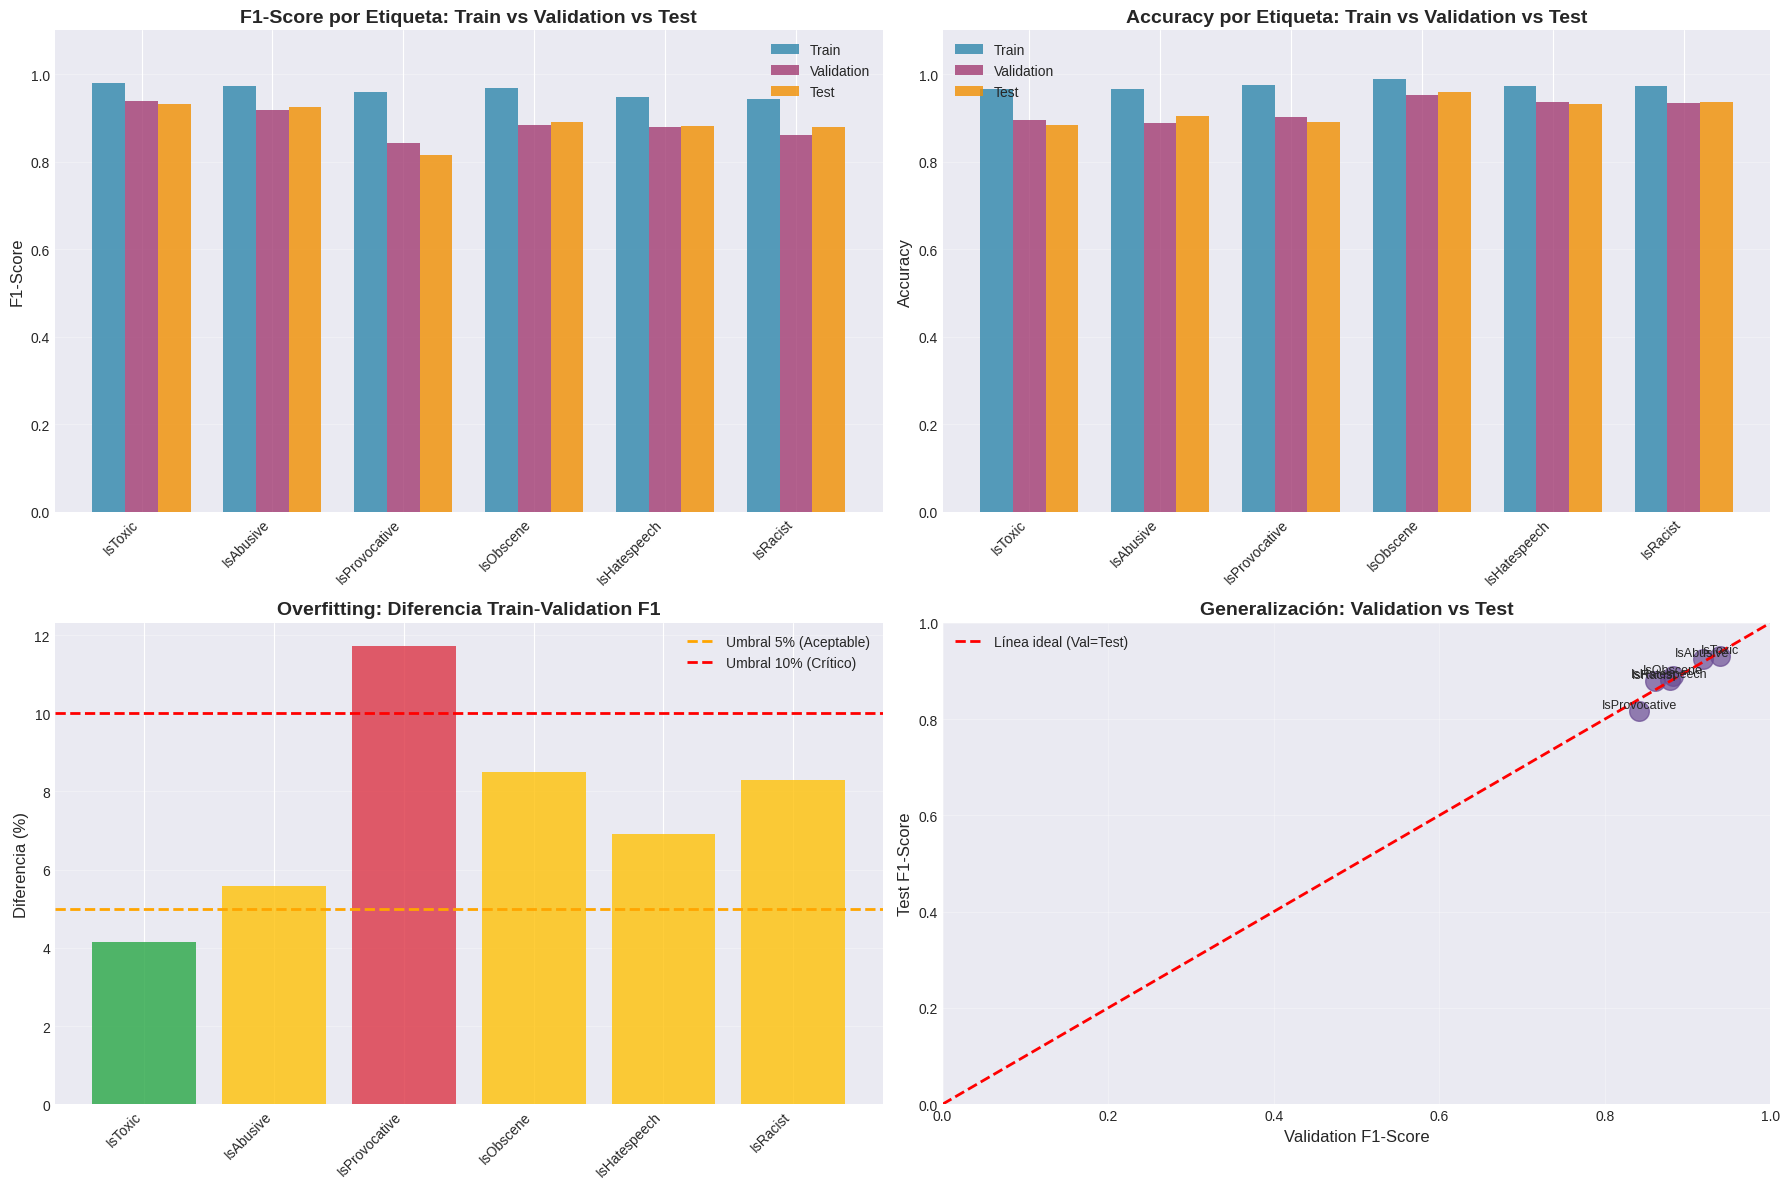

In [11]:
# Gráfico de comparación de métricas por etiqueta (Train-Validate-Test)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# F1-Score por etiqueta (Train, Validation, Test)
x = np.arange(len(labels))
width = 0.25

axes[0, 0].bar(x - width, results_df['train_f1'], width, label='Train', alpha=0.8, color='#2E86AB')
axes[0, 0].bar(x, results_df['val_f1'], width, label='Validation', alpha=0.8, color='#A23B72')
axes[0, 0].bar(x + width, results_df['test_f1'], width, label='Test', alpha=0.8, color='#F18F01')
axes[0, 0].set_ylabel('F1-Score', fontsize=12)
axes[0, 0].set_title('F1-Score por Etiqueta: Train vs Validation vs Test', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# Accuracy por etiqueta (Train, Validation, Test)
axes[0, 1].bar(x - width, results_df['train_acc'], width, label='Train', alpha=0.8, color='#2E86AB')
axes[0, 1].bar(x, results_df['val_acc'], width, label='Validation', alpha=0.8, color='#A23B72')
axes[0, 1].bar(x + width, results_df['test_acc'], width, label='Test', alpha=0.8, color='#F18F01')
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy por Etiqueta: Train vs Validation vs Test', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1.1])

# Diferencias Train-Validation (Overfitting)
colors_val = ['#28a745' if d < 5 else '#ffc107' if d < 10 else '#dc3545' for d in results_df['diff_train_val']]
axes[1, 0].bar(labels, results_df['diff_train_val'], alpha=0.8, color=colors_val)
axes[1, 0].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Umbral 5% (Aceptable)')
axes[1, 0].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Umbral 10% (Crítico)')
axes[1, 0].set_ylabel('Diferencia (%)', fontsize=12)
axes[1, 0].set_title('Overfitting: Diferencia Train-Validation F1', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(labels, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Comparación: Validation vs Test (Generalización)
axes[1, 1].scatter(results_df['val_f1'], results_df['test_f1'], s=200, alpha=0.7, color='#6A4C93')
for i, label in enumerate(labels):
    axes[1, 1].annotate(label, (results_df['val_f1'].iloc[i], results_df['test_f1'].iloc[i]), 
                       fontsize=9, ha='center', va='bottom')
axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Línea ideal (Val=Test)')
axes[1, 1].set_xlabel('Validation F1-Score', fontsize=12)
axes[1, 1].set_ylabel('Test F1-Score', fontsize=12)
axes[1, 1].set_title('Generalización: Validation vs Test', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

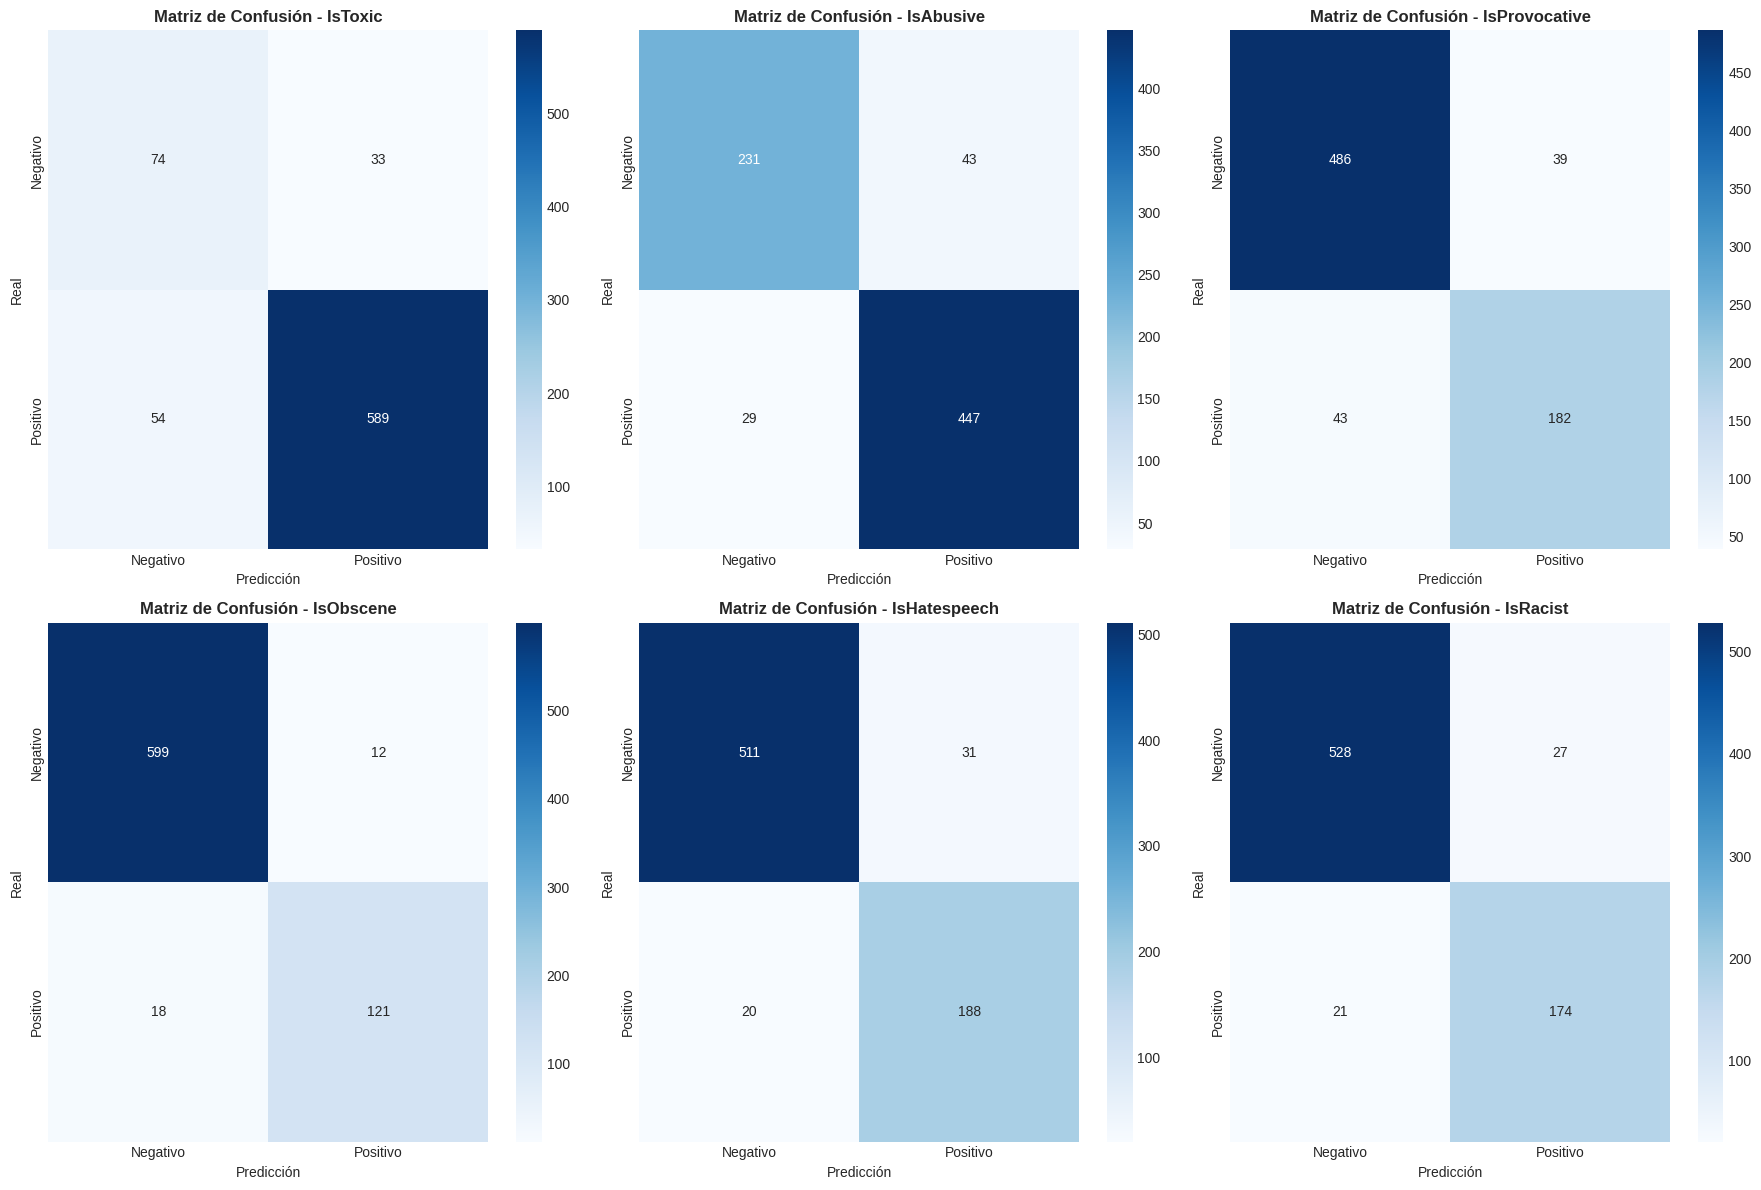

In [12]:
# Matrices de confusión para cada etiqueta
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, label in enumerate(labels):
    cm = confusion_matrix(y_test.iloc[:, i], y_test_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    axes[i].set_title(f'Matriz de Confusión - {label}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Real', fontsize=10)
    axes[i].set_xlabel('Predicción', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Reportes de Clasificación Detallados

In [13]:
# Reportes de clasificación detallados por etiqueta
for i, label in enumerate(labels):
    print(f"\n{'='*80}")
    print(f"REPORTE DE CLASIFICACIÓN - {label}")
    print(f"{'='*80}")
    
    print(f"\nTrain:")
    print(classification_report(y_train.iloc[:, i], y_train_pred[:, i], 
                                target_names=['Negativo', 'Positivo'],
                                digits=4, zero_division=0))
    
    print(f"\nValidation:")
    print(classification_report(y_val.iloc[:, i], y_val_pred[:, i], 
                                target_names=['Negativo', 'Positivo'],
                                digits=4, zero_division=0))
    
    print(f"\nTest (Evaluación Final):")
    print(classification_report(y_test.iloc[:, i], y_test_pred[:, i], 
                                target_names=['Negativo', 'Positivo'],
                                digits=4, zero_division=0))


REPORTE DE CLASIFICACIÓN - IsToxic

Train:
              precision    recall  f1-score   support

    Negativo     0.8346    0.9535    0.8901       344
    Positivo     0.9920    0.9684    0.9801      2055

    accuracy                         0.9662      2399
   macro avg     0.9133    0.9609    0.9351      2399
weighted avg     0.9695    0.9662    0.9672      2399


Validation:
              precision    recall  f1-score   support

    Negativo     0.6322    0.6395    0.6358        86
    Positivo     0.9396    0.9377    0.9387       514

    accuracy                         0.8950       600
   macro avg     0.7859    0.7886    0.7872       600
weighted avg     0.8955    0.8950    0.8953       600


Test (Evaluación Final):
              precision    recall  f1-score   support

    Negativo     0.5781    0.6916    0.6298       107
    Positivo     0.9469    0.9160    0.9312       643

    accuracy                         0.8840       750
   macro avg     0.7625    0.8038    0.7805  

## 11. Análisis de Coocurrencia de Etiquetas

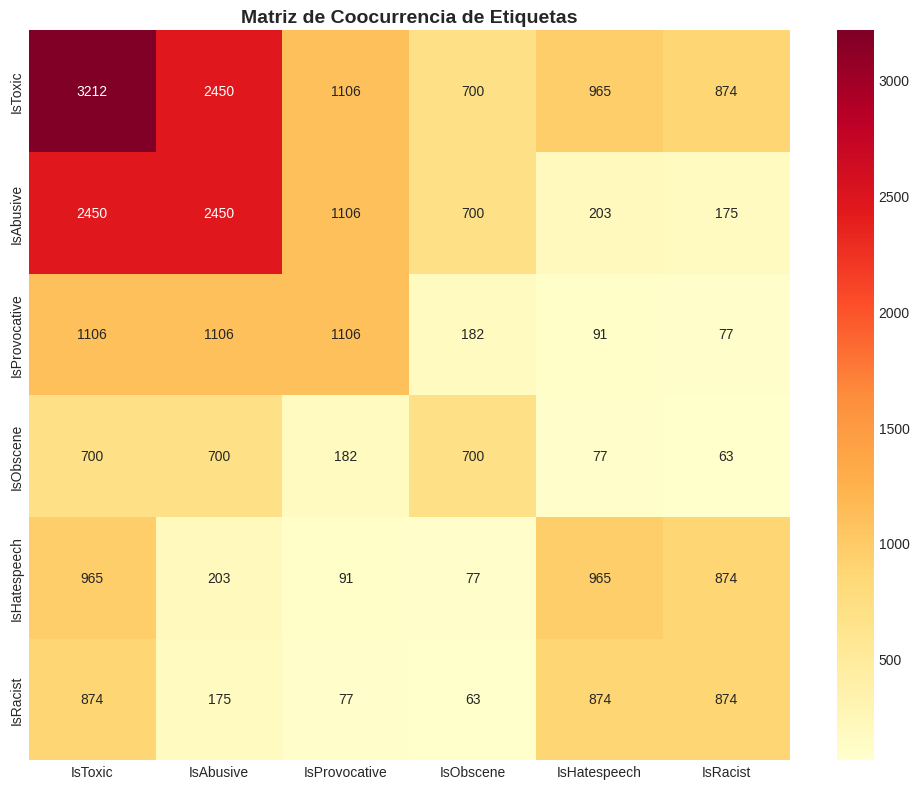


Combinaciones de etiquetas más frecuentes:
IsToxic + IsAbusive: 2450
IsToxic + IsProvocative: 1106
IsToxic + IsObscene: 700
IsToxic + IsHatespeech: 965
IsToxic + IsRacist: 874
IsAbusive + IsProvocative: 1106
IsAbusive + IsObscene: 700
IsAbusive + IsHatespeech: 203
IsAbusive + IsRacist: 175
IsProvocative + IsObscene: 182
IsProvocative + IsHatespeech: 91
IsProvocative + IsRacist: 77
IsObscene + IsHatespeech: 77
IsObscene + IsRacist: 63
IsHatespeech + IsRacist: 874


In [14]:
# Matriz de coocurrencia de etiquetas
cooccurrence = np.zeros((len(labels), len(labels)))

for i in range(len(labels)):
    for j in range(len(labels)):
        cooccurrence[i, j] = ((df[labels[i]] == 1) & (df[labels[j]] == 1)).sum()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooccurrence, annot=True, fmt='.0f', cmap='YlOrRd', 
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Matriz de Coocurrencia de Etiquetas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCombinaciones de etiquetas más frecuentes:")
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        count = cooccurrence[i, j]
        if count > 0:
            print(f"{labels[i]} + {labels[j]}: {int(count)}")

## 12. Optimización de Hiperparámetros (Opcional)

In [15]:
# Grid Search para encontrar mejores parámetros
print("Buscando mejores hiperparámetros...")

param_grid = {
    'estimator__C': [0.01, 0.1, 0.5, 1.0],  # Valores de regularización
    'estimator__class_weight': [None, 'balanced']  # Manejo de clases desbalanceadas
}

base_svm_grid = LinearSVC(random_state=42, max_iter=2000, dual=False)
svm_multilabel_grid = OneVsRestClassifier(base_svm_grid)

# Usar F1 macro como métrica
grid_search = GridSearchCV(
    svm_multilabel_grid,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor F1-Score Macro (CV): {grid_search.best_score_:.4f}")

Buscando mejores hiperparámetros...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros encontrados: {'estimator__C': 1.0, 'estimator__class_weight': 'balanced'}
Mejor F1-Score Macro (CV): 0.8999

Mejores parámetros encontrados: {'estimator__C': 1.0, 'estimator__class_weight': 'balanced'}
Mejor F1-Score Macro (CV): 0.8999


In [16]:
# Evaluar modelo optimizado con Train-Validation-Test
print("\nEvaluando modelo optimizado con los tres conjuntos...")
svm_optimized = grid_search.best_estimator_

# Generar predicciones para los tres conjuntos
y_train_pred_opt = svm_optimized.predict(X_train_tfidf)
y_val_pred_opt = svm_optimized.predict(X_val_tfidf)
y_test_pred_opt = svm_optimized.predict(X_test_tfidf)

# Evaluar usando la función correcta (Train-Validate-Test)
results_opt_df = evaluate_multilabel_model_tvt(
    y_train, y_train_pred_opt, 
    y_val, y_val_pred_opt, 
    y_test, y_test_pred_opt, 
    labels
)


Evaluando modelo optimizado con los tres conjuntos...

EVALUACIÓN DEL MODELO MULTI-ETIQUETA (Train-Validate-Test)

Etiqueta          Train F1     Val F1    Test F1    Train-Val   Train-Test     Overfitting
--------------------------------------------------------------------------------------------------------------
IsToxic             0.9937     0.9480     0.9479        4.57%        4.57%            ✓ OK
IsAbusive           0.9927     0.9335     0.9419        5.92%        5.08%          ⚠ Leve
IsProvocative       0.9872     0.8767     0.8688       11.04%       11.84%          ❌ Alto
IsObscene           0.9920     0.9098     0.9151        8.22%        7.69%          ⚠ Leve
IsHatespeech        0.9918     0.9226     0.9216        6.92%        7.02%          ⚠ Leve
IsRacist            0.9918     0.9248     0.9141        6.70%        7.77%          ⚠ Leve
--------------------------------------------------------------------------------------------------------------
PROMEDIO            0.991

## 13. Ejemplos de Predicciones

In [17]:
# Función para predecir y mostrar resultados
def predict_multilabel(text, model, vectorizer, label_names):
    """Predice etiquetas para un texto dado"""
    # Usar la función clean_text ya definida en el notebook
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    predictions = model.predict(vectorized)[0]
    
    print(f"\nTexto: {text[:200]}...")
    print(f"\nEtiquetas predichas:")
    for i, label in enumerate(label_names):
        if predictions[i] == 1:
            print(f"  ✓ {label}")
    
    if predictions.sum() == 0:
        print("  (Sin etiquetas)")
    
    print("-" * 80)

# Ejemplos del conjunto de test
print("\n" + "="*80)
print("EJEMPLOS DE PREDICCIONES")
print("="*80)

import random
random.seed(42)
sample_indices = random.sample(range(len(X_test)), 5)

for idx in sample_indices:
    text = X_test.iloc[idx]
    true_labels = y_test.iloc[idx]
    
    print(f"\nEtiquetas Reales:")
    real_labels = [labels[i] for i in range(len(labels)) if true_labels.iloc[i] == 1]
    if real_labels:
        for label in real_labels:
            print(f"  ✓ {label}")
    else:
        print("  (Sin etiquetas)")
    
    predict_multilabel(text, svm_multilabel, tfidf, labels)


EJEMPLOS DE PREDICCIONES

Etiquetas Reales:
  ✓ IsToxic
  ✓ IsAbusive

Texto: mmh ii eld already nonetheless the like moronic bullshit going on in your shit can state...

Etiquetas predichas:
  ✓ IsToxic
  ✓ IsAbusive
--------------------------------------------------------------------------------

Etiquetas Reales:
  ✓ IsToxic
  ✓ IsAbusive

Texto: thus this bitch be talk about people like dylan roof james holmes jared loughner jerad miller tim mcveigh jared loughner jim saint david adkisson apostle paul hill scott roeder frazier glen miller jr ...

Etiquetas predichas:
  ✓ IsToxic
  ✓ IsAbusive
--------------------------------------------------------------------------------

Etiquetas Reales:
  ✓ IsToxic
  ✓ IsAbusive
  ✓ IsObscene

Texto: dont you cypher them black lives matter banners being held by livid cunts is kinda patronizing and ironically racist could they have not come up with somethin better or is information technology just ...

Etiquetas predichas:
  ✓ IsToxic
  ✓ IsAbu

## 14. Resumen Final

## 14. Comparación Train-Test (80-20 Split) - Análisis Detallado

In [18]:
print("\n" + "="*120)
print(" "*40 + "📊 ANÁLISIS TRAIN-TEST (80-20 SPLIT) 📊")
print("="*120)

# Tabla de F1-Score y Overfitting
print("\n🎯 TABLA DE RESULTADOS POR ETIQUETA:")
print("="*120)
print(f"\n{'Etiqueta':<20} {'Train F1':>12} {'Test F1':>12} {'Overfitting':>15} {'Estado':>15}")
print("-" * 120)

train_test_results = []
for _, row in results_df.iterrows():
    train_f1 = row['train_f1']
    test_f1 = row['test_f1']
    overfitting = (train_f1 - test_f1) * 100  # Diferencia Train - Test en porcentaje
    
    estado = "✓ OK" if abs(overfitting) < 5 else "⚠ REVISAR" if abs(overfitting) < 10 else "❌ CRÍTICO"
    color_indicator = "🟢" if abs(overfitting) < 5 else "🟡" if abs(overfitting) < 10 else "🔴"
    
    print(f"{row['label']:<20} {train_f1:>12.4f} {test_f1:>12.4f} {overfitting:>14.2f}% {color_indicator} {estado:>12}")
    
    train_test_results.append({
        'label': row['label'],
        'train_f1': train_f1,
        'test_f1': test_f1,
        'overfitting_%': overfitting
    })

print("-" * 120)

# Promedios
avg_train_f1 = np.mean([r['train_f1'] for r in train_test_results])
avg_test_f1 = np.mean([r['test_f1'] for r in train_test_results])
avg_overfitting = (avg_train_f1 - avg_test_f1) * 100

print(f"{'PROMEDIO':<20} {avg_train_f1:>12.4f} {avg_test_f1:>12.4f} {avg_overfitting:>14.2f}%")
print("="*120)

# DataFrame para análisis posterior
train_test_df = pd.DataFrame(train_test_results)

print("\n" + "="*120)
print("📋 REPORTES DE CLASIFICACIÓN DETALLADOS POR ETIQUETA")
print("="*120)

# Reporte detallado para cada etiqueta
for i, label in enumerate(labels):
    print(f"\n{'='*120}")
    print(f"🏷️  {label}")
    print(f"{'='*120}")
    
    print(f"\n📊 TRAIN SET:")
    print(classification_report(
        y_train.iloc[:, i], 
        y_train_pred[:, i],
        target_names=['Negativo', 'Positivo'],
        digits=4,
        zero_division=0
    ))
    
    print(f"\n📊 TEST SET:")
    print(classification_report(
        y_test.iloc[:, i], 
        y_test_pred[:, i],
        target_names=['Negativo', 'Positivo'],
        digits=4,
        zero_division=0
    ))

print("\n" + "="*120)
print("📈 MÉTRICAS GLOBALES AGREGADAS (MULTI-LABEL)")
print("="*120)

# Calcular métricas agregadas manualmente para el conjunto completo
from sklearn.metrics import precision_recall_fscore_support

print("\n🔵 TRAIN SET - Métricas Agregadas:")
print("-" * 120)

for average_type in ['micro', 'macro', 'weighted', 'samples']:
    try:
        precision = precision_score(y_train, y_train_pred, average=average_type, zero_division=0)
        recall = recall_score(y_train, y_train_pred, average=average_type, zero_division=0)
        f1 = f1_score(y_train, y_train_pred, average=average_type, zero_division=0)
        
        print(f"{average_type.upper():>12} avg    precision: {precision:.4f}    recall: {recall:.4f}    f1-score: {f1:.4f}")
    except Exception as e:
        print(f"{average_type.upper():>12} avg    Error: {str(e)}")

print("\n🔵 TEST SET - Métricas Agregadas:")
print("-" * 120)

for average_type in ['micro', 'macro', 'weighted', 'samples']:
    try:
        precision = precision_score(y_test, y_test_pred, average=average_type, zero_division=0)
        recall = recall_score(y_test, y_test_pred, average=average_type, zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average=average_type, zero_division=0)
        
        print(f"{average_type.upper():>12} avg    precision: {precision:.4f}    recall: {recall:.4f}    f1-score: {f1:.4f}")
    except Exception as e:
        print(f"{average_type.upper():>12} avg    Error: {str(e)}")

print("\n" + "="*120)
print("✅ Análisis Train-Test completado")
print("="*120)


                                        📊 ANÁLISIS TRAIN-TEST (80-20 SPLIT) 📊

🎯 TABLA DE RESULTADOS POR ETIQUETA:

Etiqueta                 Train F1      Test F1     Overfitting          Estado
------------------------------------------------------------------------------------------------------------------------
IsToxic                    0.9801       0.9312           4.88% 🟢         ✓ OK
IsAbusive                  0.9737       0.9255           4.82% 🟢         ✓ OK
IsProvocative              0.9591       0.8161          14.30% 🔴    ❌ CRÍTICO
IsObscene                  0.9675       0.8897           7.77% 🟡    ⚠ REVISAR
IsHatespeech               0.9472       0.8806           6.66% 🟡    ⚠ REVISAR
IsRacist                   0.9432       0.8788           6.44% 🟡    ⚠ REVISAR
------------------------------------------------------------------------------------------------------------------------
PROMEDIO                   0.9618       0.8870           7.48%

📋 REPORTES DE CLASIFICACIÓN DE

In [19]:
print("\n" + "="*100)
print(" "*30 + "📊 OVERFITTING: TRAIN vs TEST 📊")
print("="*100)

print(f"\n{'Etiqueta':<20} {'Train F1':>12} {'Test F1':>12} {'Overfitting (Train-Test)':>30}")
print("-" * 100)

for _, row in results_df.iterrows():
    train_f1 = row['train_f1']
    test_f1 = row['test_f1']
    overfitting = (train_f1 - test_f1) * 100
    
    color = "🟢" if abs(overfitting) < 5 else "🟡" if abs(overfitting) < 10 else "🔴"
    
    print(f"{row['label']:<20} {train_f1:>12.4f} {test_f1:>12.4f} {color} {overfitting:>18.2f}%")

print("-" * 100)

# Promedios
avg_train_f1 = results_df['train_f1'].mean()
avg_test_f1 = results_df['test_f1'].mean()
avg_overfitting = (avg_train_f1 - avg_test_f1) * 100

print(f"{'PROMEDIO':<20} {avg_train_f1:>12.4f} {avg_test_f1:>12.4f}    {avg_overfitting:>18.2f}%")
print("="*100)

# Veredicto
print("\n🏆 VEREDICTO DE OVERFITTING:")
if abs(avg_overfitting) < 5:
    print(f"   ✅ Excelente - NO hay overfitting ({avg_overfitting:.2f}%)")
elif abs(avg_overfitting) < 10:
    print(f"   ⚠️  Aceptable - Overfitting LEVE ({avg_overfitting:.2f}%)")
else:
    print(f"   ❌ Crítico - Overfitting SIGNIFICATIVO ({avg_overfitting:.2f}%)")

print(f"\n📌 Overfitting máximo: {results_df['diff_train_test'].max():.2f}%")
print(f"📌 Overfitting mínimo: {results_df['diff_train_test'].min():.2f}%")


                              📊 OVERFITTING: TRAIN vs TEST 📊

Etiqueta                 Train F1      Test F1       Overfitting (Train-Test)
----------------------------------------------------------------------------------------------------
IsToxic                    0.9801       0.9312 🟢               4.88%
IsAbusive                  0.9737       0.9255 🟢               4.82%
IsProvocative              0.9591       0.8161 🔴              14.30%
IsObscene                  0.9675       0.8897 🟡               7.77%
IsHatespeech               0.9472       0.8806 🟡               6.66%
IsRacist                   0.9432       0.8788 🟡               6.44%
----------------------------------------------------------------------------------------------------
PROMEDIO                   0.9618       0.8870                  7.48%

🏆 VEREDICTO DE OVERFITTING:
   ⚠️  Aceptable - Overfitting LEVE (7.48%)

📌 Overfitting máximo: 14.30%
📌 Overfitting mínimo: 4.82%


In [20]:
print("\n" + "="*80)
print("RESUMEN FINAL DEL MODELO SVM MULTI-ETIQUETA")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   - Total de muestras: {len(df)}")
print(f"   - Entrenamiento: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Validación: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"   - Prueba: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"   - Número de etiquetas: {len(labels)}")

print(f"\n🏷️  Etiquetas:")
for label in labels:
    count = df[label].sum()
    pct = count / len(df) * 100
    print(f"   - {label}: {count} ({pct:.2f}%)")

print(f"\n🔧 Configuración del Modelo:")
print(f"   - Algoritmo: Support Vector Machine (LinearSVC)")
print(f"   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)")
print(f"   - Vectorización: TF-IDF (max_features={tfidf.max_features})")
print(f"   - Regularización C: {svm_multilabel.estimator.C}")
print(f"   - Split: Train-Validation-Test (64%-16%-20%)")

print(f"\n📈 Resumen de Métricas por Etiqueta (Test):")
print(f"\n{'Etiqueta':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['label']:<15} {row['test_acc']:>10.4f} {row['test_prec']:>10.4f} {row['test_rec']:>10.4f} {row['test_f1']:>10.4f}")

print(f"\n⚠️  Análisis de Overfitting (Train vs Validation):")
max_diff_train_val = results_df['diff_train_val'].max()
if max_diff_train_val < 5:
    print(f"   ✓ NO HAY OVERFITTING")
    print(f"   ✓ Diferencia máxima: {max_diff_train_val:.2f}% (objetivo: < 5%)")
elif max_diff_train_val < 10:
    print(f"   ⚠ OVERFITTING LEVE")
    print(f"   ⚠ Diferencia máxima: {max_diff_train_val:.2f}% (objetivo: < 5%)")
else:
    print(f"   ❌ OVERFITTING SIGNIFICATIVO")
    print(f"   ❌ Diferencia máxima: {max_diff_train_val:.2f}% (objetivo: < 5%)")

# Promedios
avg_train_f1 = results_df['train_f1'].mean()
avg_val_f1 = results_df['val_f1'].mean()
avg_test_f1 = results_df['test_f1'].mean()

print(f"\n🎯 Promedios de F1-Score:")
print(f"   Train:      {avg_train_f1:.4f}")
print(f"   Validation: {avg_val_f1:.4f}")
print(f"   Test:       {avg_test_f1:.4f} ⭐ (Rendimiento real esperado)")

print("\n" + "="*80)
print("✓ Análisis completado exitosamente")
print("="*80)


RESUMEN FINAL DEL MODELO SVM MULTI-ETIQUETA

📊 Dataset:
   - Total de muestras: 3749
   - Entrenamiento: 2399 (64.0%)
   - Validación: 600 (16.0%)
   - Prueba: 750 (20.0%)
   - Número de etiquetas: 6

🏷️  Etiquetas:
   - IsToxic: 3212 (85.68%)
   - IsAbusive: 2450 (65.35%)
   - IsProvocative: 1106 (29.50%)
   - IsObscene: 700 (18.67%)
   - IsHatespeech: 965 (25.74%)
   - IsRacist: 874 (23.31%)

🔧 Configuración del Modelo:
   - Algoritmo: Support Vector Machine (LinearSVC)
   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)
   - Vectorización: TF-IDF (max_features=5000)
   - Regularización C: 0.1
   - Split: Train-Validation-Test (64%-16%-20%)

📈 Resumen de Métricas por Etiqueta (Test):

Etiqueta          Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
IsToxic             0.8840     0.9469     0.9160     0.9312
IsAbusive           0.9040     0.9122     0.9391     0.9255
IsProvocative       0.8907     0.8235     0.8089     0.

## 15. Resumen Visual de Resultados Clave


                                   📊 RESULTADOS FINALES 📊

🎯 F1-SCORE POR ETIQUETA:

Etiqueta                 Train F1       Val F1      Test F1     Overfitting               Estado
----------------------------------------------------------------------------------------------------
IsToxic                    0.9801       0.9387       0.9312           4.14% 🟢            ✓ OK
IsAbusive                  0.9737       0.9180       0.9255           5.57% 🟡       ⚠ REVISAR
IsProvocative              0.9591       0.8418       0.8161          11.73% 🔴       ⚠ REVISAR
IsObscene                  0.9675       0.8826       0.8897           8.49% 🟡       ⚠ REVISAR
IsHatespeech               0.9472       0.8782       0.8806           6.90% 🟡       ⚠ REVISAR
IsRacist                   0.9432       0.8602       0.8788           8.30% 🟡       ⚠ REVISAR
----------------------------------------------------------------------------------------------------
PROMEDIO                   0.9618       0.8866     

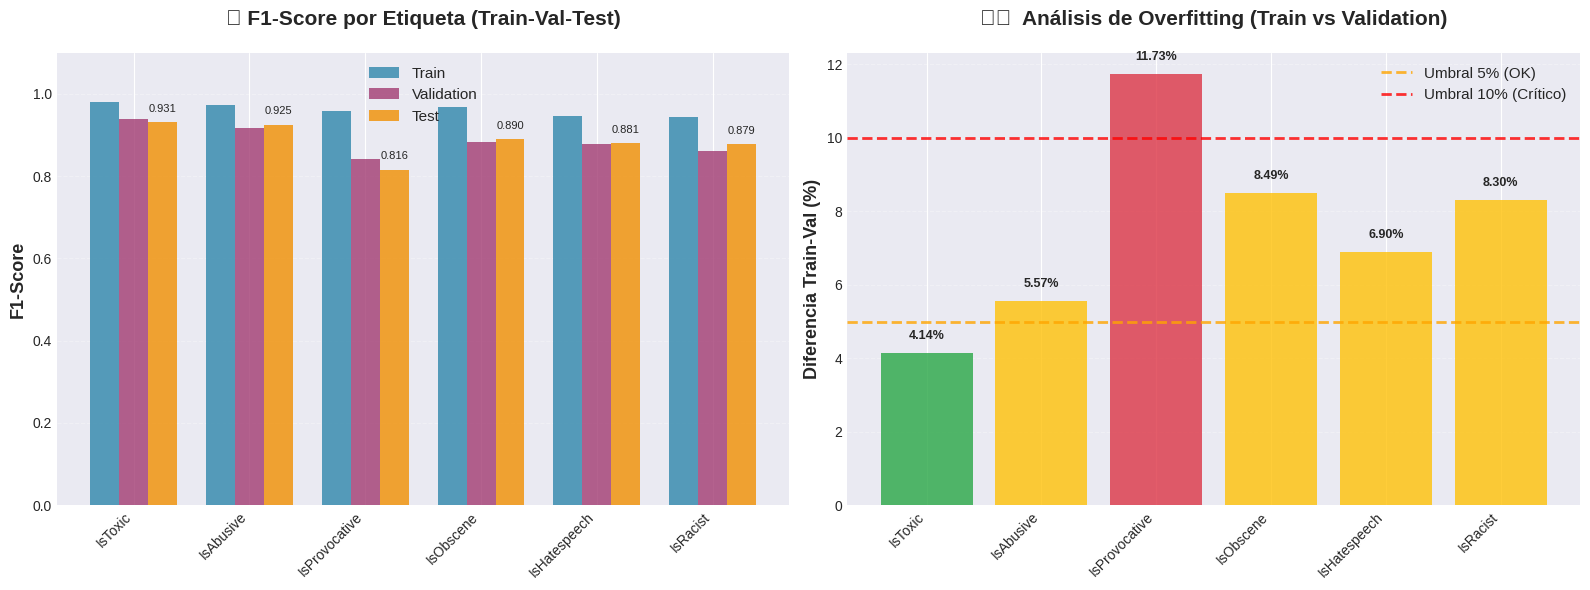


✅ Análisis completado. Revisa los gráficos y tablas arriba para los resultados completos.


In [21]:
# Tabla resumida de F1-Score y Overfitting (Train-Validate-Test)
print("\n" + "="*100)
print(" "*35 + "📊 RESULTADOS FINALES 📊")
print("="*100)

print("\n🎯 F1-SCORE POR ETIQUETA:")
print(f"\n{'Etiqueta':<20} {'Train F1':>12} {'Val F1':>12} {'Test F1':>12} {'Overfitting':>15} {'Estado':>20}")
print("-" * 100)

for _, row in results_df.iterrows():
    diff = row['diff_train_val']  # Usar diferencia Train-Validation
    estado = "✓ OK" if diff < 5 else "⚠ REVISAR"
    color_indicator = "🟢" if diff < 5 else "🟡" if diff < 10 else "🔴"
    print(f"{row['label']:<20} {row['train_f1']:>12.4f} {row['val_f1']:>12.4f} {row['test_f1']:>12.4f} {diff:>14.2f}% {color_indicator} {estado:>15}")

print("-" * 100)

# Promedio F1
avg_train_f1 = results_df['train_f1'].mean()
avg_val_f1 = results_df['val_f1'].mean()
avg_test_f1 = results_df['test_f1'].mean()
avg_diff = results_df['diff_train_val'].mean()

print(f"{'PROMEDIO':<20} {avg_train_f1:>12.4f} {avg_val_f1:>12.4f} {avg_test_f1:>12.4f} {avg_diff:>14.2f}%")

# Análisis de Overfitting
print("\n" + "="*100)
print("\n⚠️  ANÁLISIS DE OVERFITTING (Train vs Validation - Objetivo: < 5%):")
print("-" * 100)

overfitting_data = []
for _, row in results_df.iterrows():
    overfitting_data.append({
        'Etiqueta': row['label'],
        'Diff Train-Val F1 (%)': row['diff_train_val'],
        'Diff Train-Test F1 (%)': row['diff_train_test']
    })

overfitting_df = pd.DataFrame(overfitting_data).sort_values('Diff Train-Val F1 (%)', ascending=False)

for _, row in overfitting_df.iterrows():
    train_val_diff = row['Diff Train-Val F1 (%)']
    if train_val_diff < 5:
        status = "✓ Excelente (Sin overfitting)"
        icon = "🟢"
    elif train_val_diff < 10:
        status = "⚠ Aceptable (Overfitting leve)"
        icon = "🟡"
    else:
        status = "❌ Revisar (Overfitting significativo)"
        icon = "🔴"
    
    print(f"{icon} {row['Etiqueta']:<15} | Train-Val: {row['Diff Train-Val F1 (%)']:>6.2f}% | Train-Test: {row['Diff Train-Test F1 (%)']:>6.2f}% | {status}")

print("-" * 100)

# Veredicto final
max_diff_train_val = results_df['diff_train_val'].max()
etiquetas_con_overfitting = results_df[results_df['diff_train_val'] >= 5]

print("\n" + "="*100)
print("🏆 VEREDICTO FINAL:")
print("="*100)

if max_diff_train_val < 5:
    print(f"\n✅ ¡EXCELENTE! El modelo NO presenta overfitting")
    print(f"   Diferencia máxima (Train-Val): {max_diff_train_val:.2f}% (Objetivo: < 5%)")
    print(f"   Todas las {len(labels)} etiquetas cumplen con el criterio.")
elif max_diff_train_val < 10:
    print(f"\n⚠️  El modelo presenta overfitting LEVE")
    print(f"   Diferencia máxima (Train-Val): {max_diff_train_val:.2f}% (Objetivo: < 5%)")
    print(f"   Etiquetas con overfitting: {len(etiquetas_con_overfitting)} de {len(labels)}")
    if len(etiquetas_con_overfitting) > 0:
        print(f"\n   Etiquetas a revisar:")
        for _, row in etiquetas_con_overfitting.iterrows():
            print(f"      - {row['label']}: Train-Val Diff={row['diff_train_val']:.2f}%")
else:
    print(f"\n❌ El modelo presenta overfitting SIGNIFICATIVO")
    print(f"   Diferencia máxima (Train-Val): {max_diff_train_val:.2f}% (Objetivo: < 5%)")
    print(f"   Etiquetas con overfitting: {len(etiquetas_con_overfitting)} de {len(labels)}")
    if len(etiquetas_con_overfitting) > 0:
        print(f"\n   Etiquetas problemáticas:")
        for _, row in etiquetas_con_overfitting.iterrows():
            print(f"      - {row['label']}: Train-Val Diff={row['diff_train_val']:.2f}%")

print("\n" + "="*100)

# Gráfico visual compacto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: F1-Score comparativo (Train, Validation, Test)
x_pos = np.arange(len(labels))
width = 0.25

bars1 = axes[0].bar(x_pos - width, results_df['train_f1'], width, label='Train', alpha=0.8, color='#2E86AB')
bars2 = axes[0].bar(x_pos, results_df['val_f1'], width, label='Validation', alpha=0.8, color='#A23B72')
bars3 = axes[0].bar(x_pos + width, results_df['test_f1'], width, label='Test', alpha=0.8, color='#F18F01')

axes[0].set_ylabel('F1-Score', fontsize=13, fontweight='bold')
axes[0].set_title('📊 F1-Score por Etiqueta (Train-Val-Test)', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1.1])

# Añadir valores en las barras (solo para Test)
for bar in bars3:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Análisis de Overfitting (Train-Validation)
colors = ['#28a745' if d < 5 else '#ffc107' if d < 10 else '#dc3545' for d in results_df['diff_train_val']]
bars = axes[1].bar(labels, results_df['diff_train_val'], alpha=0.8, color=colors)

axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Umbral 5% (OK)', alpha=0.8)
axes[1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Umbral 10% (Crítico)', alpha=0.8)
axes[1].set_ylabel('Diferencia Train-Val (%)', fontsize=13, fontweight='bold')
axes[1].set_title('⚠️  Análisis de Overfitting (Train vs Validation)', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars, results_df['diff_train_val'])):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Análisis completado. Revisa los gráficos y tablas arriba para los resultados completos.")

In [22]:
# Análisis detallado del desbalance de clases
print("="*100)
print("📊 ANÁLISIS DE BALANCE DE CLASES")
print("="*100)

print("\n🔍 Distribución de etiquetas en el conjunto de entrenamiento:\n")
print(f"{'Etiqueta':<20} {'Positivos':>12} {'Negativos':>12} {'% Positivos':>15} {'Ratio':>10}")
print("-" * 100)

label_stats = []
for label in labels:
    pos_count = y_train[label].sum()
    neg_count = len(y_train) - pos_count
    pos_pct = (pos_count / len(y_train)) * 100
    ratio = f"1:{int(neg_count/pos_count)}" if pos_count > 0 else "N/A"
    
    print(f"{label:<20} {pos_count:>12} {neg_count:>12} {pos_pct:>14.2f}% {ratio:>10}")
    
    label_stats.append({
        'label': label,
        'pos_count': pos_count,
        'neg_count': neg_count,
        'pos_pct': pos_pct,
        'test_f1': results_df[results_df['label'] == label]['test_f1'].values[0]
    })

stats_df = pd.DataFrame(label_stats)

print("\n" + "="*100)
print("\n🎯 ESTRATEGIAS DE DATA AUGMENTATION RECOMENDADAS:")
print("="*100)

# Clasificar etiquetas por severidad del problema
critical = stats_df[stats_df['pos_pct'] < 5]  # Menos del 5% de ejemplos positivos
moderate = stats_df[(stats_df['pos_pct'] >= 5) & (stats_df['pos_pct'] < 15)]
good = stats_df[stats_df['pos_pct'] >= 15]

print("\n🔴 CRÍTICAS (< 5% ejemplos positivos) - Requieren MUCHO data augmentation:")
if len(critical) > 0:
    for _, row in critical.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
    print(f"   → Objetivo: Aumentar a al menos 200-300 ejemplos por etiqueta")
else:
    print("   ✓ Ninguna")

print("\n🟡 MODERADAS (5-15% ejemplos positivos) - Requieren data augmentation moderado:")
if len(moderate) > 0:
    for _, row in moderate.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
    print(f"   → Objetivo: Aumentar a al menos 150-200 ejemplos")
else:
    print("   ✓ Ninguna")

print("\n🟢 BUENAS (> 15% ejemplos positivos) - Pueden necesitar augmentation ligero:")
if len(good) > 0:
    for _, row in good.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
else:
    print("   ✓ Ninguna")

print("\n" + "="*100)
print("\n💡 TÉCNICAS DE DATA AUGMENTATION SUGERIDAS:")
print("="*100)
print("""
1. **Back-Translation (Más efectivo):**
   - Traducir textos a otro idioma y volver a inglés
   - Preserva el significado pero con diferentes palabras
   - Herramientas: Google Translate API, MarianMT, DeepL
   - Ejemplo: EN → ES → EN, EN → FR → EN, EN → DE → EN

2. **Synonym Replacement:**
   - Reemplazar palabras con sinónimos
   - Usar WordNet, PPDB (Paraphrase Database)
   - Mantener palabras clave de toxicidad

3. **Random Insertion:**
   - Insertar palabras relacionadas en posiciones aleatorias
   - Usar sinónimos del contexto

4. **Random Swap:**
   - Intercambiar posiciones de palabras aleatorias
   - Mantener estructura gramatical básica

5. **Contextual Word Embeddings (BERT-based):**
   - Usar BERT para generar paráfrasis contextualmente apropiadas
   - Más avanzado pero más preciso

6. **Easy Data Augmentation (EDA):**
   - Combinación de las técnicas anteriores
   - Biblioteca: nlpaug, textaugment

7. **Recolección manual adicional:**
   - Buscar más ejemplos reales en otros datasets
   - Datasets sugeridos: Jigsaw Toxic Comments, HateXplain, etc.
""")

print("\n📋 PLAN DE ACCIÓN RECOMENDADO:")
print("="*100)
print("""
Paso 1: Identificar textos de entrenamiento para cada clase minoritaria
Paso 2: Aplicar Back-Translation (3-5 traducciones por texto original)
Paso 3: Aplicar Synonym Replacement (2-3 variaciones por texto)
Paso 4: Revisar manualmente una muestra para verificar calidad
Paso 5: Combinar datos originales + augmentados
Paso 6: Re-entrenar modelo SVM base con el dataset balanceado
Paso 7: Evaluar mejora en F1-Score y overfitting
""")

print("\n🔧 EJEMPLO DE IMPLEMENTACIÓN:")
print("="*100)
print("""
# Opción 1: Usar nlpaug
import nlpaug.augmenter.word as naw

# Back Translation
back_trans_aug = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de',
    to_model_name='facebook/wmt19-de-en'
)

# Synonym Replacement
syn_aug = naw.SynonymAug(aug_src='wordnet')

# Opción 2: Usar textaugment
from textaugment import EDA
eda = EDA()

# Aplicar transformaciones
augmented_texts = []
for text in minority_class_texts:
    augmented_texts.append(eda.synonym_replacement(text))
    augmented_texts.append(eda.random_insertion(text))
    augmented_texts.append(eda.random_swap(text))
""")

📊 ANÁLISIS DE BALANCE DE CLASES

🔍 Distribución de etiquetas en el conjunto de entrenamiento:

Etiqueta                Positivos    Negativos     % Positivos      Ratio
----------------------------------------------------------------------------------------------------
IsToxic                      2055          344          85.66%        1:0
IsAbusive                    1574          825          65.61%        1:0
IsProvocative                 699         1700          29.14%        1:2
IsObscene                     435         1964          18.13%        1:4
IsHatespeech                  608         1791          25.34%        1:2
IsRacist                      546         1853          22.76%        1:3


🎯 ESTRATEGIAS DE DATA AUGMENTATION RECOMENDADAS:

🔴 CRÍTICAS (< 5% ejemplos positivos) - Requieren MUCHO data augmentation:
   ✓ Ninguna

🟡 MODERADAS (5-15% ejemplos positivos) - Requieren data augmentation moderado:
   ✓ Ninguna

🟢 BUENAS (> 15% ejemplos positivos) - Pueden necesita

## 16. Guardar Modelo y Vectorizador

In [23]:
# import joblib
# import os

# # Crear directorio para guardar modelos si no existe
# model_dir = '../resources/models/'
# os.makedirs(model_dir, exist_ok=True)

# # Guardar el modelo SVM multi-etiqueta
# model_path = os.path.join(model_dir, 'svm_multilabel_model.pkl')
# joblib.dump(svm_multilabel, model_path)
# print(f"✓ Modelo guardado en: {model_path}")

# # Guardar el vectorizador TF-IDF
# vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')
# joblib.dump(tfidf, vectorizer_path)
# print(f"✓ Vectorizador guardado en: {vectorizer_path}")

# # Guardar las etiquetas utilizadas
# labels_path = os.path.join(model_dir, 'labels.pkl')
# joblib.dump(labels, labels_path)
# print(f"✓ Etiquetas guardadas en: {labels_path}")

# # Guardar métricas del modelo para referencia
# metrics_path = os.path.join(model_dir, 'model_metrics.csv')
# results_df.to_csv(metrics_path, index=False)
# print(f"✓ Métricas guardadas en: {metrics_path}")

# print("\n" + "="*80)
# print("🎉 MODELO GUARDADO EXITOSAMENTE")
# print("="*80)